# Exploratory Data Analysis — M5, `CA_1` / `FOODS`

This looks at the 35-SKU sample pulled from Kaggle's M5 Forecasting
Accuracy dataset (`src/data_loader.py`): one Walmart store (`CA_1`),
one category (`FOODS`), monthly demand from Jan 2011 to May 2016.

The goal here isn't to build any forecasting logic yet — it's to actually
look at the data first, the way a real analysis would start, before
deciding how to model it.

In [9]:
import sys
sys.path.append("..")  # so `from src import config` resolves when running from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config

monthly = pd.read_csv(config.PROCESSED_DIR / "monthly_demand.csv", parse_dates=["Date"])
calendar = pd.read_csv(config.RAW_DIR / "calendar.csv", parse_dates=["date"])

(config.PROJECT_ROOT / "outputs" / "figures").mkdir(parents=True, exist_ok=True)

monthly.head()

,Date,Product_Family,SKU,Demand
0,2011-01-01,FOODS_1,FOODS_1_124,0
1,2011-02-01,FOODS_1,FOODS_1_124,0
2,2011-03-01,FOODS_1,FOODS_1_124,43
3,2011-04-01,FOODS_1,FOODS_1_124,16
4,2011-05-01,FOODS_1,FOODS_1_124,61


In [10]:
print(f"{monthly['SKU'].nunique()} SKUs, {monthly['Date'].nunique()} months, {len(monthly)} rows")
print(f"Date range: {monthly['Date'].min().date()} -> {monthly['Date'].max().date()}")
monthly.groupby("Product_Family")["SKU"].nunique().rename("SKU count").to_frame()

35 SKUs, 65 months, 2275 rows
Date range: 2011-01-01 -> 2016-05-01


,SKU count
Product_Family,
FOODS_1,4
FOODS_2,6
FOODS_3,25


## Chart styling

One style block, set once, instead of leaving every chart on matplotlib's
defaults — this is what actually distinguishes a deliberately-made chart
from a templated one: consistent colors tied to something meaningful
(product family), no boxed-in axes, no auto-generated titles.

In [11]:
PALETTE = {
    "FOODS_1": "#4C72B0",
    "FOODS_2": "#DD8452",
    "FOODS_3": "#55A868",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#444444",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#E3E3E3",
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.dpi": 100,
})

## 1. Which product family actually drives volume?

`FOODS_3` has by far the most SKUs in this sample (25 of 35) purely
because it has far more items in the full CA_1/FOODS category to begin
with — worth checking whether it also dominates *volume*, or whether a
handful of high-turnover SKUs in a smaller family matter just as much.

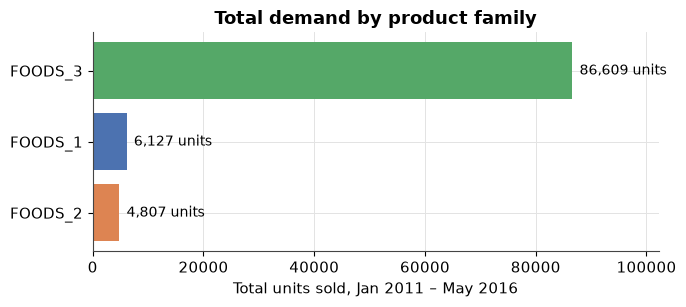

In [12]:
family_totals = monthly.groupby("Product_Family")["Demand"].sum().sort_values()

fig, ax = plt.subplots(figsize=(7, 3.2))
bars = ax.barh(family_totals.index, family_totals.values,
                color=[PALETTE[f] for f in family_totals.index])
for bar, val in zip(bars, family_totals.values):
    ax.text(val + family_totals.max() * 0.015, bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f} units", va="center", fontsize=10)

ax.set_xlim(0, family_totals.max() * 1.18)
ax.set_xlabel("Total units sold, Jan 2011 – May 2016")
ax.set_title("Total demand by product family")
fig.tight_layout()
fig.savefig(config.PROJECT_ROOT / "outputs" / "figures" / "family_volume.png", dpi=150)
plt.show()

## 2. Not every SKU behaves the same way

Rather than eyeballing all 35 lines at once (the kind of chart that reads
as templated because nobody could actually read it), pick out a few
genuinely different demand shapes using simple, honest statistics:

- **steadiest**: lowest coefficient of variation among nonzero months
- **spikiest**: highest coefficient of variation among nonzero months
- **most intermittent**: highest share of zero-demand months

This mirrors the ADI/CV² logic the demand-classification module will
formalize later — here it's just picking examples to look at.

In [13]:
def cv_nonzero(s):
    nz = s[s > 0]
    return nz.std() / nz.mean() if len(nz) > 1 else np.nan

profiles = monthly.groupby("SKU")["Demand"].agg(
    pct_zero_months=lambda s: (s == 0).mean(),
    mean_demand="mean",
    cv_nonzero=cv_nonzero,
)
profiles.sort_values("pct_zero_months", ascending=False).head()

,pct_zero_months,mean_demand,cv_nonzero
SKU,,,
FOODS_3_371,0.692308,4.107692,0.589951
FOODS_2_395,0.584615,5.076923,0.598377
FOODS_3_429,0.538462,20.861538,0.456277
FOODS_3_027,0.476923,22.076923,0.591452
FOODS_2_045,0.476923,14.707692,0.425858


In [14]:
steady_sku = profiles["cv_nonzero"].idxmin()
spiky_sku = profiles["cv_nonzero"].idxmax()
intermittent_sku = profiles["pct_zero_months"].idxmax()

example_skus = [steady_sku, spiky_sku, intermittent_sku]
example_labels = ["Steadiest (lowest CV)", "Spikiest (highest CV)", "Most intermittent (most zero months)"]
example_skus

['FOODS_3_596', 'FOODS_3_564', 'FOODS_3_371']

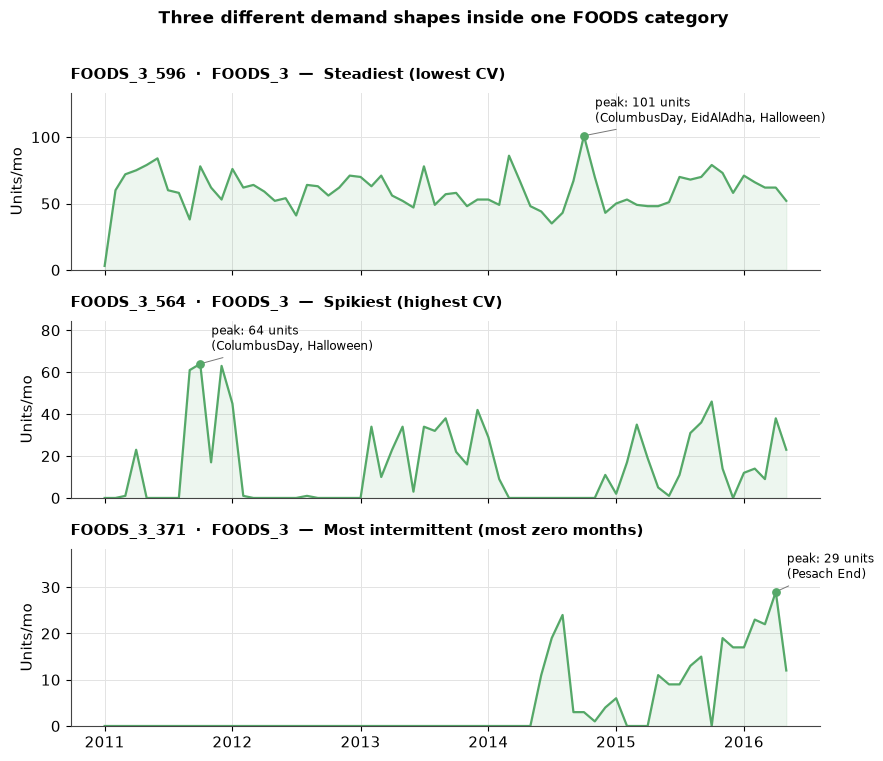

In [15]:
calendar["Month"] = calendar["date"].dt.to_period("M").dt.to_timestamp()
events_by_month = (
    calendar.dropna(subset=["event_name_1"])
    .groupby("Month")["event_name_1"]
    .apply(lambda x: ", ".join(sorted(set(x))))
)

def plot_sku(sku, label, ax):
    family = monthly.loc[monthly["SKU"] == sku, "Product_Family"].iloc[0]
    color = PALETTE[family]
    s = monthly[monthly["SKU"] == sku].set_index("Date")["Demand"]

    ax.plot(s.index, s.values, color=color, linewidth=1.6)
    ax.fill_between(s.index, s.values, color=color, alpha=0.10)

    peak_date, peak_val = s.idxmax(), s.max()
    ax.scatter([peak_date], [peak_val], color=color, zorder=5, s=28)
    peak_month = peak_date.to_period("M").to_timestamp()
    note = f"peak: {peak_val:.0f} units"
    if peak_month in events_by_month.index:
        note += f"\n({events_by_month.loc[peak_month]})"
    ax.annotate(note, xy=(peak_date, peak_val), xytext=(8, 10),
                textcoords="offset points", fontsize=8.5,
                arrowprops=dict(arrowstyle="-", color="#777777", lw=0.7))

    ax.set_ylim(0, s.max() * 1.32)  # headroom so the annotation clears the title above it
    ax.set_title(f"{sku}  ·  {family}  —  {label}", loc="left", fontsize=10.5, pad=10)
    ax.set_ylabel("Units/mo")

fig, axes = plt.subplots(len(example_skus), 1, figsize=(9, 7.5), sharex=True)
for ax, sku, label in zip(axes, example_skus, example_labels):
    plot_sku(sku, label, ax)
fig.suptitle("Three different demand shapes inside one FOODS category", fontsize=12.5, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(config.PROJECT_ROOT / "outputs" / "figures" / "example_skus.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Portfolio-level pattern over time

All 35 SKUs summed together, month by month, with a 12-month centered
rolling average to separate any real trend/seasonality from month-to-month
noise.

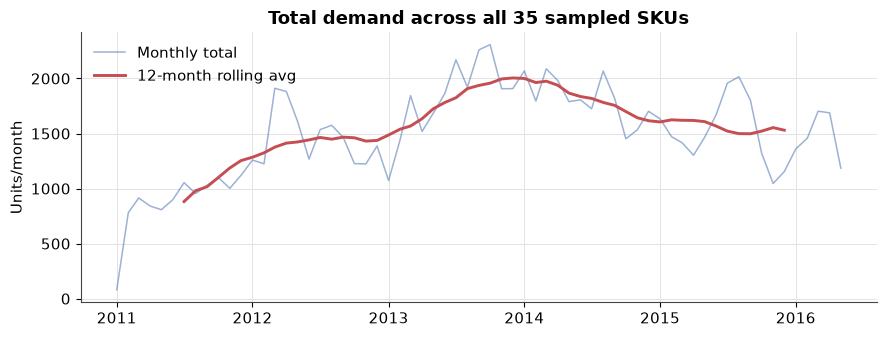

In [16]:
portfolio = monthly.groupby("Date")["Demand"].sum()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(portfolio.index, portfolio.values, color="#4C72B0", linewidth=1.1, alpha=0.55, label="Monthly total")
ax.plot(portfolio.index, portfolio.rolling(12, center=True).mean(), color="#C44E52", linewidth=2.1, label="12-month rolling avg")
ax.legend(frameon=False, loc="upper left")
ax.set_title("Total demand across all 35 sampled SKUs")
ax.set_ylabel("Units/month")
fig.tight_layout()
fig.savefig(config.PROJECT_ROOT / "outputs" / "figures" / "portfolio_trend.png", dpi=150)
plt.show()

## Takeaways

*(Fill this in yourself once you've actually looked at the charts above —
don't let me write your conclusions for real data I haven't seen run. A
few questions to answer from what's on screen:)*

- Does one product family really dominate total volume, or is it closer
  than the SKU-count split (4/6/25) would suggest?
- Do the three example SKUs above look like they'd need genuinely
  different forecasting approaches? Which one looks hardest?
- Is there a visible trend or seasonal pattern in the portfolio total, or
  does it look mostly flat/noisy over 5+ years?
- Do any of the annotated peaks line up with a real calendar event, or do
  they look unrelated to the events data?